In [116]:
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy.signal import freqz
import pywt

Creating Filters

In [117]:
f = [ .038580777748 , .126969125396 , -.077161555496 , -.607491641386 ,
.745687558934 , -.226584265197 ]

In [118]:
y = -((-1) ** np.arange(1, len(f) + 1)) * f

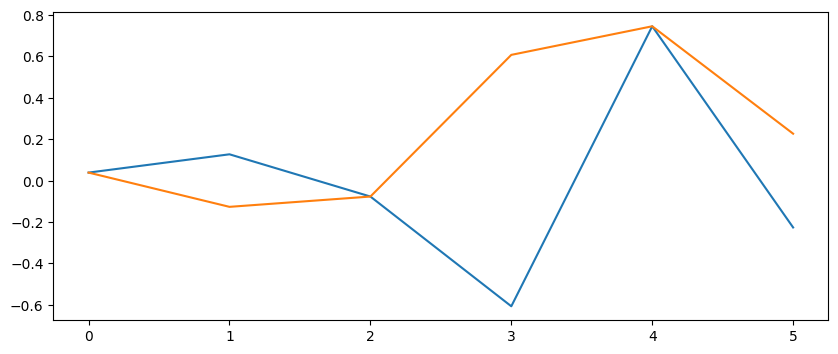

In [119]:
plt.figure(figsize=(10, 4))
plt.plot(f)
plt.plot(y)
plt.show()

# 1. Analysis of simple signal

Creating simple signal

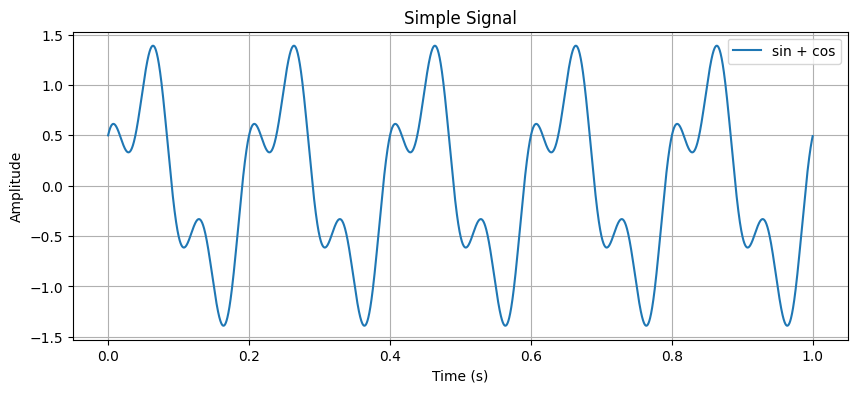

In [120]:
# Sampling parameters
L = 12
fs = 2**L  # Sampling frequency (Hz)
T = 1      # Duration (seconds)
t = np.linspace(0, T, fs*T, endpoint=False)  # Time vector

# Define frequencies and amplitudes
f1, f2 = 5, 15  # Hz
A1, A2 = 1.0, 0.5  # Amplitudes

# Create signal: sum of sin and cos
simple_signal = A1 * np.sin(2 * np.pi * f1 * t) + A2 * np.cos(2 * np.pi * f2 * t)

# Plot the signal
plt.figure(figsize=(10, 4))
plt.plot(t, simple_signal, label="sin + cos")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Simple Signal")
plt.legend()
plt.grid(True)
plt.show()

In [121]:
def cyclic_convolve(signal, filt):
    N = len(signal)
    filt = np.pad(filt, (0, N - len(filt)))
    return np.real(np.fft.ifft(np.fft.fft(signal) * np.fft.fft(filt)))[::2]


In [122]:
def dwt_recursive(signal, lowpass, highpass, levels):
    coeffs = []
    current = signal.copy()
    for _ in range(levels):
        detail = cyclic_convolve(current, highpass)
        approx = cyclic_convolve(current, lowpass)
        coeffs.append(detail)
        current = approx 
    coeffs.append(current)
    return coeffs


In [123]:
def central_frequency(filt):
    w, h = freqz(filt)
    magnitude = np.abs(h)
    peak_index = np.argmax(magnitude)
    return w[peak_index] / (2 * np.pi)


In [124]:
def plot_scalogram(coeffs):
    plt.figure(figsize=(10, 6))
    for i, c in enumerate(coeffs[:-1]): 
        norm_c = c / np.max(np.abs(c))  
        plt.plot(norm_c + i * 2, label=f"Detail L{len(coeffs)-2 - i}")
    plt.legend()
    plt.title("DWT Scalogram")
    plt.xlabel("Sample")
    plt.ylabel("Amplitude")
    plt.grid()
    plt.show()

In [125]:
limit_of_filter = math.floor(np.log2(len(f)))
limit_of_filter

2

In [126]:
n = np.log2(len(simple_signal))
n = math.floor(n)

In [127]:
dwted_signal = dwt_recursive(simple_signal, f, y, n-limit_of_filter)

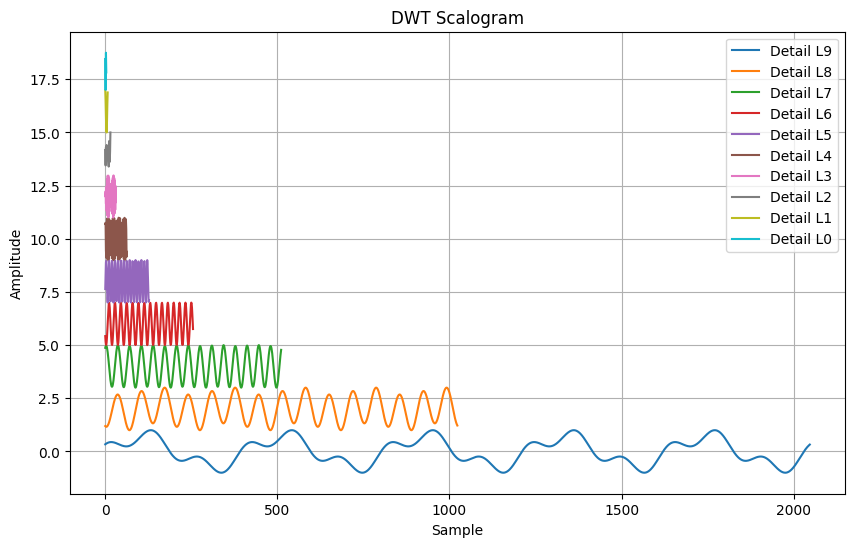

In [128]:
plot_scalogram(dwted_signal)

In [129]:
def scaled_frequencies(filt, max_levels, fs):
    f0 = central_frequency(filt)
    freqs = [f0 / (2 ** j) * fs for j in range(1, max_levels + 1)]
    return freqs

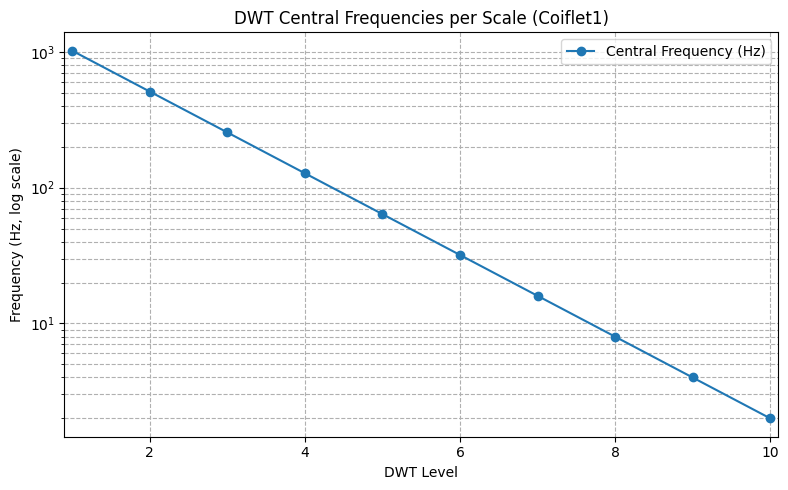

In [130]:
max_lvls = n - limit_of_filter
freqs_hz = scaled_frequencies(f, n-limit_of_filter, fs)

# Plot the frequencies on a vertical axis (log scale)
plt.figure(figsize=(8, 5))
plt.plot(range(1, max_lvls + 1), freqs_hz, 'o-', label="Central Frequency (Hz)")
plt.yscale('log')
plt.title("DWT Central Frequencies per Scale (Coiflet1)")
plt.xlim(0.9, 10.1)
plt.xlabel("DWT Level")
plt.ylabel("Frequency (Hz, log scale)")
plt.grid(True, which='both', ls='--')
plt.legend()
plt.tight_layout()
plt.show()

Normalisation was used for clearer results

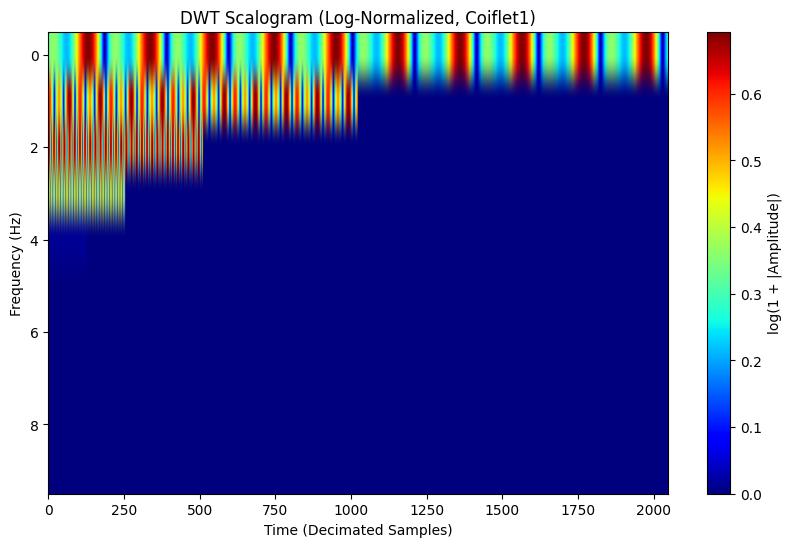

In [131]:
coeffs = dwt_recursive(simple_signal, f, y, max_lvls)

# Create a matrix for heatmap (pad to match width)
max_len = max(len(c) for c in coeffs[:-1])
# Apply log-normalization for better visual contrast
log_norm_matrix = np.array([
    np.log1p(np.pad(np.abs(c) / (np.max(np.abs(c)) + 1e-10), 
                    (0, max_len - len(c))))
    for c in coeffs[:-1]
])

# Plot the improved scalogram
plt.figure(figsize=(10, 6))
plt.imshow(log_norm_matrix, aspect='auto', cmap='jet')
plt.title("DWT Scalogram (Log-Normalized, Coiflet1)")
plt.ylabel("Frequency (Hz)")
plt.xlabel("Time (Decimated Samples)")
plt.colorbar(label="log(1 + |Amplitude|)")
plt.grid(False)
plt.show()

/home/tymon/Desktop/SATFD/.venv/lib/python3.12/site-packages/pywt/_multilevel.py:43: UserWarning: Level value of 10 is too high: all coefficients will experience boundary effects.
  warnings.warn(


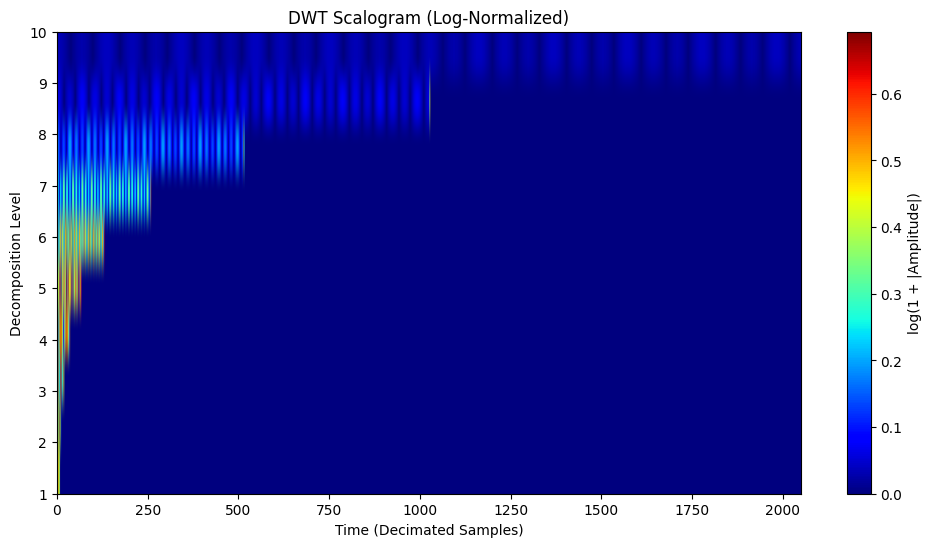

In [132]:
coif1 = pywt.Wavelet('coif1')
widths = np.arange(1, max_lvls+1)
coeffs = pywt.wavedec(simple_signal, coif1, level=max_lvls)

detail_coeffs = coeffs[1:]
max_len = max(len(c) for c in detail_coeffs)

log_norm_matrix = np.array([
    np.log1p(np.pad(np.abs(c) / (np.max(np.abs(c)) + 1e-10),
                    (0, max_len - len(c))))
    for c in detail_coeffs[::-1] 
])

# Plot
plt.figure(figsize=(12, 6))
plt.imshow(log_norm_matrix, aspect='auto', cmap='jet',
           extent=[0, max_len, 1, max_lvls])
plt.title(f"DWT Scalogram (Log-Normalized)")
plt.ylabel("Decomposition Level")
plt.xlabel("Time (Decimated Samples)")
plt.colorbar(label="log(1 + |Amplitude|)")
plt.grid(False)
plt.show()

We obtain similar results, but they differ in how each level is normalised

# Analysis of rabarbar.wav

In [133]:
from scipy.io import wavfile

# Load WAV file
fs, data = wavfile.read("rabarbar8k.wav")
data.shape

(47310,)

Preparing the signal for analysis

In [134]:
data = data - np.mean(data)

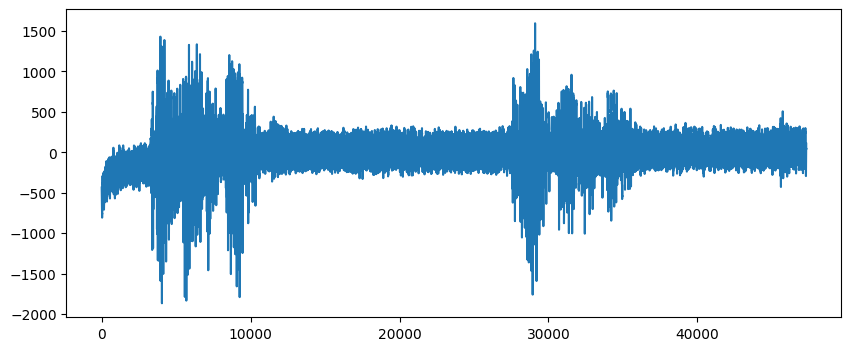

In [135]:
plt.figure(figsize=(10, 4))
plt.plot(data)
plt.show()

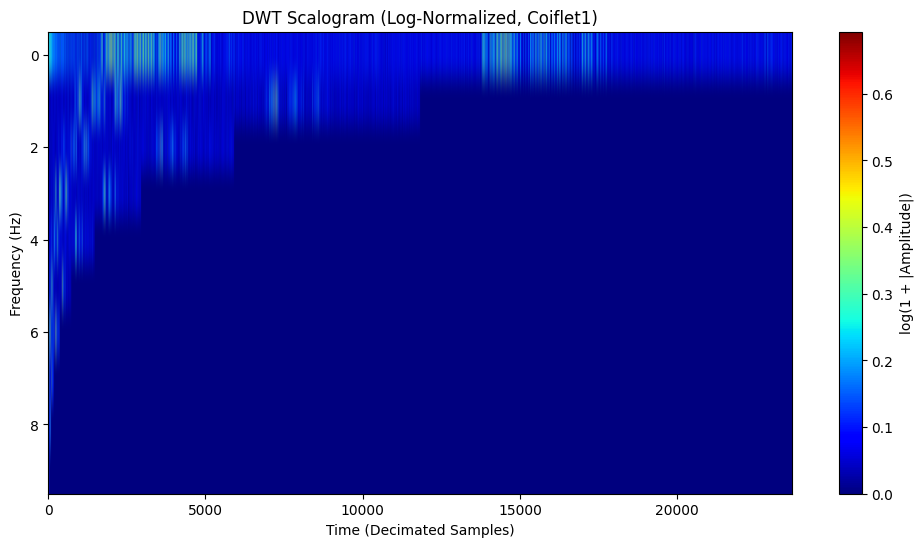

In [136]:
coeffs = dwt_recursive(data, f, y, max_lvls)

# Create a matrix for heatmap (pad to match width)
max_len = max(len(c) for c in coeffs[:-1])
# Apply log-normalization for better visual contrast
log_norm_matrix = np.array([
    np.log1p(np.pad(np.abs(c) / (np.max(np.abs(c)) + 1e-10), 
                    (0, max_len - len(c))))
    for c in coeffs[:-1]
])

# Plot
plt.figure(figsize=(12, 6))
plt.imshow(log_norm_matrix, aspect='auto', cmap='jet')
plt.title("DWT Scalogram (Log-Normalized, Coiflet1)")
plt.ylabel("Frequency (Hz)")
plt.xlabel("Time (Decimated Samples)")
plt.colorbar(label="log(1 + |Amplitude|)")
plt.grid(False)
plt.show()

We can see where sound is stronger

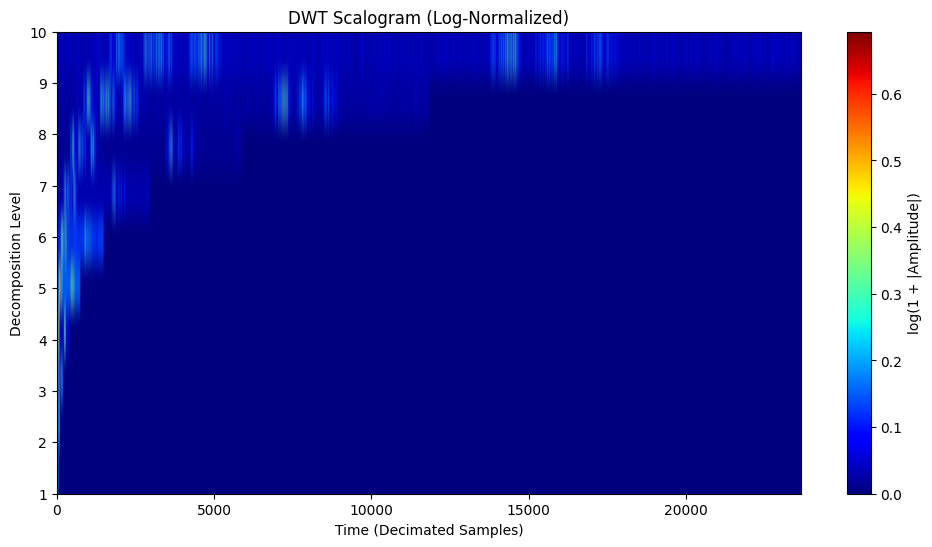

In [137]:
coif1 = pywt.Wavelet('coif1')
widths = np.arange(1, max_lvls+1)
coeffs = pywt.wavedec(data, coif1, level=max_lvls)

detail_coeffs = coeffs[1:] 
max_len = max(len(c) for c in detail_coeffs)

log_norm_matrix = np.array([
    np.log1p(np.pad(np.abs(c) / (np.max(np.abs(c)) + 1e-10),
                    (0, max_len - len(c))))
    for c in detail_coeffs[::-1]  
])

# Plot
plt.figure(figsize=(12, 6))
plt.imshow(log_norm_matrix, aspect='auto', cmap='jet',
           extent=[0, max_len, 1, max_lvls])
plt.title(f"DWT Scalogram (Log-Normalized)")
plt.ylabel("Decomposition Level")
plt.xlabel("Time (Decimated Samples)")
plt.colorbar(label="log(1 + |Amplitude|)")
plt.grid(False)
plt.show()

Again we can see taht on deeper levels values are higher on DWT Scalogram obtained by pywt